In [5]:
import numpy as np
import scipy.constants as const
import matplotlib.pyplot as plt
from dataclasses import dataclass
import xarray as xr
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

from scipy.special import k0

## Constants and calibrational data

In [6]:
# ------------------ Physical constants ------------------
Phi_0 = const.physical_constants['mag. flux quantum'][0] #'Wb' h/(2e)
pi = const.pi
h = const.h # J s
hbar = const.hbar # J s
e = const.e # C
k_B = const.k # J K-1
Delta_Al = 3.4e-4*e # J


# ------------------ System parameters ------------------
T = 40e-3 #K
Ec= 0.233e9*h #JAC
C = e**2/(2*Ec) #F

Ej = [38.844, 39.119, 40.903, 42.825, 45.982, 48.452, 47.903, 53.394, 53.394, 60.531, 57.649, 65.473, 61.080, 68.904, 67.257]  # GHz

jj_area = [380**2, 390**2, 400**2, 410**2, 420**2, 430**2, 440**2, 450**2, 460**2, 470**2, 480**2, 490**2, 500**2, 510**2, 520**2]  # nm^2

## Data loading and preprocessing

In [57]:
def process_datasets(two_tone_path, t1_path, flux_scale, flux_offset, pad_length):
    two_tone_ds = xr.load_dataset(two_tone_path)
    t1_ds = xr.load_dataset(t1_path)

    ds_copy = two_tone_ds.copy(deep=True)

    flux_f01 = ds_copy.setpoint + flux_offset
    freq_f01 = ds_copy.f01

    # Filtering T1 data
    valid_idx = (t1_ds.T1 < 40e-6) & ~np.isnan(t1_ds.T1) & (t1_ds.T1_err < 1e-6)
    clean_flux = t1_ds.setpoint[valid_idx]
    clean_t1 = t1_ds.T1[valid_idx]
    clean_t1_err = t1_ds.T1_err[valid_idx]

    flux_t1 = clean_flux*flux_scale  + flux_offset
    data_t1 = clean_t1

    # Padding
    padded_flux = np.pad(clean_flux, (0, pad_length - len(clean_flux)), 'constant')
    padded_t1 = np.pad(clean_t1, (0, pad_length - len(clean_flux)), 'constant')
    padded_t1_err = np.pad(clean_t1_err, (0, pad_length - len(clean_flux)), 'constant')

    # Replace zeroes with NaN
    t1_nan = np.where(padded_t1 == 0, np.nan, padded_t1)
    t1_err_nan = np.where(padded_t1_err == 0, np.nan, padded_t1_err)

    return {
        'flux_f01': flux_f01,
        'freq_f01': freq_f01,
        'flux_t1': flux_t1,
        'data_t1': data_t1,
        'padded_flux': padded_flux,
        'padded_t1': t1_nan,
        'padded_t1_err': t1_err_nan
    }


In [ ]:
dataset_1 = process_datasets(
    "Data/Q2_DS_1/DS_1_sweep_qcodes_f01_combined.hdf5",
    "Data/Q2_DS_1/DS_1_sweep_qcodes_t1_combined.hdf5",
    flux_scale = 1.0753,
    flux_offset=1.775,
    pad_length=228
)

dataset_2 = process_datasets(
    "Data/Q2_DS_2/DS_2_sweep_quantify_f01_combined.hdf5",
    "Data/Q2_DS_2/DS_2_sweep_quantify_t1_combined.hdf5",
    flux_scale = 1.0753, 
    flux_offset=1.77631,
    pad_length=228
)

dataset_3 = process_datasets(
    "Data/Q2_DS_3/DS_3_sweep_quantify_f01_combined.hdf5",
    "Data/Q2_DS_3/DS_3_sweep_quantify_t1_combined.hdf5",
    flux_scale = 1.0753, 
    flux_offset=1.778,
    pad_length=364
)

dataset_4 = process_datasets(
    "Data/Q2_DS_4/DS_4_sweep_quantify_f01_combined.hdf5",
    "Data/Q2_DS_4/DS_4_sweep_quantify_t1_combined.hdf5",
    flux_scale = 1.0753, 
    flux_offset=1.7788,
    pad_length=364
)

## Hamiltonian construction

In [ ]:
def build_phase_hamiltonians(
        EJ1: float,
        EJ2: float,
        EJ3: float,
        EJ4: float,
        EJ5: float,
        flux1: np.ndarray,
        flux2: float,
        phis: np.ndarray,
        Ec: float,
        ng: float,
) -> np.ndarray:

    """
    Construct phase-basis Hamiltonians for a superconducting circuit.
    """
    # ----------------- Phase grid -----------------
    phis = phis * 2*np.pi
    N = len(phis)
    delta_phi = phis[1] - phis[0]

    # ----------------- Differential operators -----------------
        # First derivative
    D1 = np.eye(N,k=1) - np.eye(N,k=-1)
    D1[0,-1] = -1
    D1[-1,0] = 1
    D1 /= (2*delta_phi)

    # Second derivative (Laplacian)
    D2 = -2*np.eye(N) + np.eye(N,k=1) + np.eye(N,k=-1)
    D2[0,-1] = D2[-1,0] = 1
    D2 /= delta_phi**2

    # ----------------- Kinetic term -----------------
    T = 4*Ec * (-D2 + 2j*ng*D1 + ng**2*np.eye(N))
    
    # ----------------- Effective left arm SQUID parameters -----------------
    d = abs(EJ4 - EJ5)/abs(EJ4 + EJ5)
    EJsum = EJ4 + EJ5

    EJ45eff =  EJsum * np.sqrt((np.cos(np.pi*flux2))**2 + d**2*(np.sin(np.pi*flux2))**2)

    # Transmission coefficients (clipped for stability)
    t1 =  4*EJ1 *EJ2/(EJ1 + EJ2)**2
    t1 = np.clip(t1, 0.0, 1.0)

    t2 =  4*EJ3 *EJ45eff/(EJ3 + EJ45eff)**2
    t2 = np.clip(t2, 0.0, 1.0)

    # ----------------- Capacitances & charging energies for internal modes -----------------

    CJ1 = get_CJ(EJ1)
    CJ2 = get_CJ(EJ2)
    CJ3 = get_CJ(EJ3)
    CJ45 = get_CJ(EJ4) + get_CJ(EJ5)

    C_mod_L = CJ1 + CJ2
    EC_mod_L = e**2/(2*C_mod_L*h)*1e-9

    C_mod_R = CJ3 + CJ45
    EC_mod_R = e**2/(2*C_mod_R*h)*1e-9

    # ----------------- Energy scales -----------------
    E_L = EJ1 + EJ2
    E_R = EJ3 + EJ45eff

    # ----------------- Grid reshaping -----------------
    phi_grid = phis[None, :]                  # shape (1, N)
    flux1_grid = flux1[:, None] 

    V = np.zeros((len(flux1), N, N), dtype=float)

    # ----------------- Potential energy prefactors -----------------
    PF_L = np.sqrt(1 - t1 * np.sin((phi_grid)/2)**2)
    PF_L -= np.sqrt(2*EC_mod_L/E_L  * np.sqrt(1 - t1 * np.sin(phi_grid/2)**2))

    PF_R = np.sqrt(1 - t2 * np.sin((phi_grid - 2*np.pi*flux1_grid)/2)**2)
    PF_R -= np.sqrt(2*EC_mod_R/E_R  * np.sqrt(1 - t2 * np.sin((phi_grid - 2*np.pi*flux1_grid)/2)**2))

    # ----------------- Potential energy -----------------
    V_phi = -(E_L * PF_L + E_R * PF_R)

    # Build diagonal potential matrices
    V = np.array([np.diag(v_row) for v_row in V_phi])  

    # Effective EJ
    EJ_eff = -np.min(V_phi, axis=1)

    # ----------------- Full Hamiltonian -----------------
    H_all = V + T[None, :, :] 

    return H_all, phis, EJ_eff

In [ ]:
a, b = np.polyfit(jj_area, Ej, 1)

def get_junction_area(Ej):
    area = (Ej-b)/a
    return area

def get_CJ(EJ1):
    C_per_Area = 50e-15 #50 fF/mum^2
    
    area_EJ1 = get_junction_area(EJ1)*1e-6
    CJ1 =  C_per_Area*area_EJ1
    
    return CJ1

# Compute qubit properties

In [ ]:
def n_operator_phase(N, delta_phi, ng=0.0):
    # central finite difference for derivative
    t = 1 / (2 * delta_phi)
    n_op = np.zeros((N, N), dtype=complex)
    
    # off-diagonal elements
    for i in range(N-1):
        n_op[i, i+1] = -1j * t
        n_op[i+1, i] = 1j * t
    
    # periodic boundary
    n_op[0, -1] = 1j * t
    n_op[-1, 0] = -1j * t
    
    # offset by ng
    n_op -= ng * np.eye(N)
    
    return n_op

In [ ]:
def compute_qubit_properties_phase(EJ1, EJ2, EJ3, EJ4, EJ5, flux1, flux2, phi, Ec):
    
    # Build Hamiltonians
    H_all, phis, EJ_eff = build_phase_hamiltonians(EJ1=EJ1, EJ2=EJ2, EJ3=EJ3,EJ4=EJ4, EJ5=EJ5, flux1=flux1, flux2=flux2, phis=phi, Ec= EC, ng = 0.0)


    # Phase grid
    N = len(phis)
    phi_grid = phis[None, :]
    flux1_grid = flux1[:, None]

    # ------------------ Effective parameters ------------------
    d = abs(EJ4 - EJ5)/abs(EJ4 + EJ5)
    
    EJsum = EJ4 + EJ5

    EJ45eff =  EJsum * np.sqrt((np.cos(np.pi*flux2))**2 + d**2*(np.sin(np.pi*flux2))**2)

    EJR = (EJ3 + EJ45eff)
    EJL = EJ1 + EJ2

    t1 =  4*EJ1 *EJ2/(EJ1 + EJ2)**2

    t2 =  4*EJ3 *EJ45eff/(EJ3 + EJ45eff)**2
    
    t1, t2 = np.clip(t1, 0, 1), np.clip(t2, 0, 1)
    

    # ------------------ Charging energies ------------------
    CJ1 = get_CJ(EJ1)
    CJ2 = get_CJ(EJ2)
    CJ3 = get_CJ(EJ3)
    CJ45 = get_CJ(EJ4) + get_CJ(EJ5)

    C_mod = CJ45 + CJ3
    EC_mod = e**2/(2*C_mod*h)*1e-9

    C_mod_L = CJ1 + CJ2
    EC_mod_L = e**2/(2*C_mod_L*h)*1e-9


    # ------------------ Operators ------------------

    delta_phi = phis[1] - phis[0]
    n_op = n_operator_phase(N, delta_phi)

    qp_op_L = np.diag(np.sin(phis/2))# independent of flux
    qp_op_R = np.sin((phi_grid  - 2*np.pi*flux1_grid)/2)# independent of flux

    phi_op = np.diag(phis)

    # ==========================DERIVATIVE OPERATORS (FLUX)================================

    # ------------- Change parqameters------------

    theta = (phi_grid - 2*np.pi*flux1_grid)/2
    
    PF_R = np.sqrt(1 - t2 * np.sin(theta)**2)

    sqrt =  np.sqrt(np.cos(np.pi*flux2)**2 + d**2*np.sin(np.pi*flux2)**2)

    d_EJ45eff_dflux2 = EJsum*(np.pi/2)*(d**2-1)*np.sin(2*np.pi*flux2)/(sqrt)

    #  -------- Main potential d flux2 ------
    
    d_t2_d_flux2 = 4*EJ3*(1/EJR)**3*(EJ3-EJ45eff)*d_EJ45eff_dflux2

    d_PF_R_d_t2 = -1/2*(np.sin(theta))**2/PF_R
    
    # -------- Internal mode contribution (flux2) --------

    d_sqrt_EJR_dflux2 = (1/2)*np.sqrt(1/EJR)*d_EJ45eff_dflux2

    d_sqrt_sqrt_PF_dflux2 = (-1/4)*(np.sin(theta))**2*(1 - t2 * (np.sin(theta)**2))**(-3/4)*d_t2_d_flux2

    d_int_mode_dflux2 = np.sqrt(2*EC_mod)*( 
                                                d_sqrt_EJR_dflux2 *(1 - t2 * np.sin(theta)**2)**(1/4)
                                                + np.sqrt(EJR)*d_sqrt_sqrt_PF_dflux2
                                            )

    #  -------- Deriative over flux1 ------
    
    d_EJR_d_flux1 = EJR*t2*(np.pi) * np.sin((2*theta))/(2*np.sqrt(1 - t2 * (np.sin(theta))**2))

    d_int_mode_d_flux1 = np.sqrt(2*EC_mod*EJR)*1/4*t2*(np.pi)*np.sin(2*theta)/(1 - t2 * (np.sin(theta))**2)**(3/4)

    # -------- Total derivatives --------

    d_H_d_flux1 = -(d_EJR_d_flux1 - d_int_mode_d_flux1)

    d_H_d_flux2 = -(d_EJ45eff_dflux2*PF_R + EJR*d_PF_R_d_t2*d_t2_d_flux2 - d_int_mode_dflux2)

    return (n_op, phi_op, d_H_d_flux1, d_H_d_flux2, qp_op_L, qp_op_R, EJL, EJR, EJ_eff)



# B matrix implementation Charge

In [ ]:
def Charge_SD(f01, A_cap, alpha):

    prefactor = (2*e)**2 / hbar**2
    
    omega01 = 2 * np.pi * f01*1e9  # Convert GHz to rad/s

    therm_ratio = hbar * omega01 / (k_B * T)
    coth = 1 / np.tanh(0.5 * therm_ratio)
    thermal_factor = (1 + coth)
    
    EC = 0.21
    CJ = e**2 / (2 * EC * 1e9 * h)

    Q_cap = A_cap * (f01/ 3)**(-alpha)
    S_cap = prefactor * (omega01 * hbar) / (np.abs(omega01) * CJ * Q_cap) * coth
    
    return S_cap


### Purcell here

In [37]:
def Purcell_SD(f01, g):

    Q_L = 4.6e4

    f_r = 5.2344

    Delta = 2*np.pi*(f01 - f_r) * 1e9  # Hz

    kappa = 2 * np.pi * f_r * 1e9 / Q_L # Hz

    
    Gamma_purcell = ((g*2*np.pi)**2* kappa) / (Delta**2)

    
    return Gamma_purcell

### FBL

In [38]:
def FBL_SD_1(f01, M1):
    
    omega01 = 2 * np.pi * f01*1e9  # Convert GHz to rad/s

    therm_ratio = hbar * omega01 / (k_B * T)
    coth = 1 / np.tanh(0.5 * therm_ratio)
    thermal_factor = (1 + coth)
    
    R = 50

    S_flux1_line = (h * 1e9)**2*(M1**2*omega01*hbar/R)*thermal_factor

    Gamma_flux1_line = (1 / hbar**2) * S_flux1_line

    
    return Gamma_flux1_line


### 1/f flux noise

In [39]:
def one_over_f_SD(f01, A_lambda, gamma):

    omega01 = 2 * np.pi * f01 * 1e9  # Convert GHz to rad/s

    S_lambda = 2*np.pi*A_lambda**2/(omega01)**gamma
 
    SD_lambda =  (1 / hbar**2) * (h * 1e9)**2 *  S_lambda 
    
    return SD_lambda 

### Inductive noise

In [40]:
def stable_K0_sinh(x):
    x = np.array(x)

    out = np.zeros_like(x)

    # small x
    small = x < 1e-3
    out[small] = -np.log(x[small]) * x[small]  # leading behavior

    # large x
    large = x > 50
    out[large] = np.sqrt(np.pi / (2 * x[large])) / 2

    # mid region (safe)
    mid = ~(small | large)
    out[mid] = k0(x[mid]) * np.sinh(x[mid])

    return out

def Inductive_SD(f01, EJeff,  A_ind):

    omega01 = 2 * np.pi * f01 * 1e9  # Convert GHz to rad/s

    therm_ratio = hbar * omega01 / (k_B * T)
    coth = 1 / np.tanh(0.5 * therm_ratio)

    
    omega_ref = 2 * np.pi * 0.5e9  # rad/s
    arg_ref = hbar * omega_ref / (2 * k_B * T)                                  

    Q_ind = A_ind * (k0(arg_ref) * np.sinh(arg_ref)) / stable_K0_sinh(therm_ratio)
    # print(f"Q_ind at f01: {Q_ind}")
    

    LJ = (Phi_0/(2*np.pi))**2/(EJeff*h*1e9)

    # Spectral density S(ω)
    S_ind = hbar / (LJ * Q_ind) * (coth/(1+np.exp(-therm_ratio)))                                                
    
    coeff = ((Phi_0)/(2*np.pi))**2

                                      
    SD_ind = coeff*hbar**(-2)*S_ind
    
    return SD_ind


In [41]:
def Inductive_SD(f01, EJeff, A_ind):
    omega01 = 2 * np.pi * f01 * 1e9
    therm_ratio = hbar * omega01 / (k_B * T)

    # --- Safe coth ---
    if np.abs(therm_ratio) < 1e-6:
        coth = 2 / (therm_ratio + 1e-12)  # series expansion for small x
    else:
        coth = 1 / np.tanh(0.5 * therm_ratio)

    # --- Reference ---
    omega_ref = 2 * np.pi * 0.5e9
    arg_ref = hbar * omega_ref / (2 * k_B * T)

    # Safe k0 * sinh
    denom = k0(therm_ratio) * np.sinh(therm_ratio)
    if denom == 0 or not np.isfinite(denom):
        return 0.0  # fallback to 0

    Q_ind = A_ind * (k0(arg_ref) * np.sinh(arg_ref)) / denom

    LJ = (Phi_0/(2*np.pi))**2/(EJeff*h*1e9)

    if Q_ind == 0 or not np.isfinite(Q_ind):
        return 0.0

    exp_term = np.exp(-therm_ratio)
    if not np.isfinite(exp_term):
        exp_term = 0.0

    S_ind = hbar / (LJ * Q_ind) * (coth / (1 + exp_term))

    coeff = ((Phi_0)/(2*np.pi))**2
    SD_ind = coeff * hbar**(-2) * S_ind

    # Clamp SD_ind to finite
    if not np.isfinite(SD_ind):
        SD_ind = 0.0

    return SD_ind

# Quasiparticle

In [42]:
def QP_SD(f01, EJi, x_qp):
    
    omega01 = 2 * np.pi * f01 * 1e9  # Convert GHz to rad/s

    therm_ratio = hbar * omega01 / (k_B * T)
    coth = 1 / np.tanh(0.5 * therm_ratio)
    thermal_factor = (1 + coth)

    Delta = 3.4e-4 * e  

    Rk = h/e**2
    prefactor = np.sqrt(2/np.pi)
    
    energy_ratio_i = (8*EJi*1e9*h/(Rk*Delta))
    
    gap_term = (2*Delta/(hbar*omega01))**(3/2)

    ReY_i = x_qp*prefactor*energy_ratio_i*gap_term*np.sqrt(0.5*therm_ratio)*k0(0.5*therm_ratio)*np.sinh(0.5*therm_ratio)

    S_qp_i = 2*(Phi_0/(hbar*np.pi))**2*hbar*omega01*ReY_i*(1+coth)

    return S_qp_i


## New version

In [43]:
def rates_with_B_core(evals, evecs, get_B_op, spec_func, get_spec_args, T):
    n_flux, n_levels = evals.shape

    Gamma_all = np.zeros((n_flux, n_levels, n_levels))
    T1_all = np.full((n_flux, n_levels), np.inf)
    B_all = np.zeros((n_flux, n_levels, n_levels))
    Gamma_eff_all = np.full((n_flux, n_levels), np.inf)
    T1_eff_all = np.full((n_flux, n_levels), np.inf)

    for idx in range(n_flux):
        U = evecs[idx]
        B_op = get_B_op(idx, U)

        f_Hz = evals[idx] * 1e9
        Gamma = np.zeros((n_levels, n_levels))

        spec_args = get_spec_args(idx)

        # --- Γ ---
        for i in range(n_levels):
            for j in range(n_levels):
                if evals[idx, i] > evals[idx, j]:
                    delta_f = f_Hz[i] - f_Hz[j]
                    modsq = np.abs(B_op[j, i])**2

                    S_val = spec_func(delta_f * 1e-9, **spec_args)

                    Gamma[i, j] = modsq * S_val
                    Gamma[j, i] = Gamma[i, j] * np.exp(-h * delta_f / (k_B * T))

        Gamma_all[idx] = Gamma

        # --- B ---
        B = np.zeros_like(Gamma)
        for i in range(n_levels):
            B[i, i] = -np.sum(Gamma[i, :])
            for j in range(n_levels):
                if i != j:
                    B[i, j] = Gamma[j, i]

        B_all[idx] = B

        # --- T1 ---
        for i in range(n_levels):
            total_down = np.sum(Gamma[i, f_Hz < f_Hz[i]])
            if total_down > 0:
                T1_all[idx, i] = 1.0 / total_down

        # --- effective decay ---
        eigvals, eigvecs = np.linalg.eig(B)
        V_inv = np.linalg.inv(eigvecs)

        max_ev = np.max(np.abs(eigvals))
        mask = np.abs(eigvals) > max_ev * 1e-6
        eigvals_masked = eigvals[mask]

        for i_init in range(n_levels):
            p0 = np.zeros(n_levels)
            p0[i_init] = 1.0

            c = V_inv @ p0
            overlaps = np.abs(c[mask])**2

            gamma_eff = np.sum(overlaps * (-np.real(eigvals_masked))) / np.sum(overlaps)

            if gamma_eff > 0:
                Gamma_eff_all[idx, i_init] = gamma_eff
                T1_eff_all[idx, i_init] = 1.0 / gamma_eff

    return  T1_all, T1_eff_all

In [44]:
def rates_with_B_cap(evals, evecs, n_op, spec_func, spec_args, T):

    def get_B_op(idx, U):
        return U.conj().T @ n_op @ U

    def get_spec_args(idx):
        return spec_args

    return rates_with_B_core(
        evals, evecs,
        get_B_op,
        spec_func,
        get_spec_args,
        T
    )

In [45]:
def rates_with_B_ind(evals, evecs, phi_op, spec_func, spec_args, T):

    def get_B_op(idx, U):
        return U.conj().T @ phi_op @ U

    def get_spec_args(idx):
        args = spec_args.copy()
        args["EJeff"] = spec_args["EJeff"][idx]
        return args

    return rates_with_B_core(evals, evecs, get_B_op, spec_func, get_spec_args, T)

In [46]:
def rates_with_B_flux(evals, evecs, dH1, dH2, spec_func, spec_args, T):

    def get_B_op(idx, U):
        d1 = np.diag(dH1[idx])
        d2 = np.diag(dH2[idx])
        return U.conj().T @ d1 @ U + U.conj().T @ d2 @ U

    def get_spec_args(idx):
        return spec_args

    return rates_with_B_core(evals, evecs, get_B_op, spec_func, get_spec_args, T)

In [47]:
def rates_with_B_purcell(evals, evecs, n_op, spec_func, spec_args, T):

    def get_B_op(idx, U):
        return U.conj().T @ n_op @ U

    def get_spec_args(idx):
        return spec_args

    return rates_with_B_core(
        evals, evecs,
        get_B_op,
        spec_func,
        get_spec_args,
        T
    )

In [48]:
def build_all_noise_specs(noise, EJeff=None):
    """
    Maps NoiseParams → structured spec dictionaries for all noise channels.
    """

    specs = {}

    # --- Capacitive noise ---
    specs["cap"] = {
        "A_cap": noise.A_cap,
        "alpha": noise.alpha_cap
    }

    # --- Inductive noise (flux-dependent EJ) ---
    if EJeff is None:
        specs["ind"] = {"A_ind": noise.A_ind}
    else:
        specs["ind"] = {
            "A_ind": noise.A_ind,
            "EJeff": EJeff
        }

    # --- 1/f flux noise ---
    specs["flux_1f"] = {
        "A_lambda": noise.A_lambda,
        "gamma": noise.gamma
    }

    # --- FBL flux noise ---
    specs["FBL"] = {
        "M1": noise.M1
    }

    # --- second flux channel (if needed separately) ---
    specs["FBL2"] = {
        "M2": noise.M2
    }

    # --- Purcell noise ---
    specs["purcell"] = {
        "g": noise.g
    }

    # --- quasiparticle noise ---
    specs["qp"] = {
        "x_qp": noise.x_qp
    }

    return specs



In [49]:
def rates_with_B_flux_uncorrelated(
    evals, evecs,
    dH1, dH2,
    spec_func,       # single function
    spec_args_list,  # list of dicts
    T
):
    n_flux, n_levels = evals.shape

    Gamma_all = np.zeros((n_flux, n_levels, n_levels))
    T1_all = np.full((n_flux, n_levels), np.inf)
    B_all = np.zeros((n_flux, n_levels, n_levels))
    Gamma_eff_all = np.full((n_flux, n_levels), np.inf)
    T1_eff_all = np.full((n_flux, n_levels), np.inf)

    for idx in range(n_flux):
        U = evecs[idx]

        # operators
        B1 = U.conj().T @ np.diag(dH1[idx]) @ U
        B2 = U.conj().T @ np.diag(dH2[idx]) @ U

        f_Hz = evals[idx] * 1e9
        Gamma = np.zeros((n_levels, n_levels))

        for i in range(n_levels):
            for j in range(n_levels):
                if evals[idx, i] > evals[idx, j]:

                    delta_f = f_Hz[i] - f_Hz[j]
                    omega_GHz = delta_f * 1e-9

                    # --- sum of independent contributions ---
                    rate = 0.0

                    # for spec_func, spec_args_list in zip(spec_funcs, spec_args_list):

                    S1 = spec_func(omega_GHz, **spec_args_list[0])

                    if len(spec_args_list) > 1:
                        S2 = spec_func(omega_GHz, **spec_args_list[1])
                    else:
                        S2 = S1

                    rate = (
                        np.abs(B1[j, i])**2 * S1 +
                        np.abs(B2[j, i])**2 * S2
                    )

                    Gamma[i, j] = rate
                    Gamma[j, i] = rate * np.exp(-h * delta_f / (k_B * T))

        Gamma_all[idx] = Gamma

        # --- B matrix ---
        B = np.zeros_like(Gamma)
        for i in range(n_levels):
            B[i, i] = -np.sum(Gamma[i, :])
            for j in range(n_levels):
                if i != j:
                    B[i, j] = Gamma[j, i]

        B_all[idx] = B

        # --- T1 ---
        for i in range(n_levels):
            total_down = np.sum(Gamma[i, f_Hz < f_Hz[i]])
            if total_down > 0:
                T1_all[idx, i] = 1.0 / total_down

        # --- effective decay ---
        eigvals, eigvecs = np.linalg.eig(B)
        V_inv = np.linalg.inv(eigvecs)

        max_ev = np.max(np.abs(eigvals))
        mask = np.abs(eigvals) > max_ev * 1e-6
        eigvals_masked = eigvals[mask]

        for i_init in range(n_levels):
            p0 = np.zeros(n_levels)
            p0[i_init] = 1.0

            c = V_inv @ p0
            overlaps = np.abs(c[mask])**2

            gamma_eff = np.sum(overlaps * (-np.real(eigvals_masked))) / np.sum(overlaps)

            if gamma_eff > 0:
                Gamma_eff_all[idx, i_init] = gamma_eff
                T1_eff_all[idx, i_init] = 1.0 / gamma_eff

    return T1_all, T1_eff_all

In [50]:
def run_qubit_calculation(
        EJ1, EJ2, EJ3, EJ4, EJ5,
        EC, ng, n_levels,
        flux2,
        noise,
        phi, phi_ext):

    # Prepare flux grids
    H_all, phis, EJ_eff = build_phase_hamiltonians(
    EJ1=EJ1, EJ2=EJ2, EJ3=EJ3, EJ4=EJ4, EJ5 = EJ5,
    phis=phi, flux1=phi_ext, flux2=flux2,  Ec= EC, ng = ng,
    )


    evals, evecs = np.linalg.eigh(H_all)

    n_keep = n_levels

    evals_sel = evals[:,  :n_keep]     # (201, n_levels)
    evecs_sel = evecs[:, :, :n_keep]  # (201, dim, n_levels)

    # Compute qubit parameters
    n_op, phi_op, d_H_d_flux1, d_H_d_flux2, qp_op_L, qp_op_R, EJL, EJR, EJeff = compute_qubit_properties_phase(
    EJ1=EJ1, EJ2=EJ2, EJ3=EJ3, EJ4=EJ4, EJ5 = EJ5,
    flux1=phi_ext,
    flux2=flux2,
    phi=phi,
    Ec= EC
    )
    

    specs = build_all_noise_specs(noise, EJeff=EJeff)

    # Individual channels
    T1_all_cap, T1_eff_all_cap = rates_with_B_cap(
    evals_sel,
    evecs_sel,
    n_op,
    spec_func=Charge_SD,
    spec_args=specs["cap"],
    T=T)

    T1_all_FBL, T1_eff_all_FBL = rates_with_B_flux_uncorrelated(
    evals_sel,
    evecs_sel,
    d_H_d_flux1,
    d_H_d_flux2,
    spec_func=FBL_SD_1,
    spec_args_list=[specs["FBL"]],
    T=T
)

    T1_all_ind, T1_eff_all_ind = rates_with_B_ind(
    evals_sel,
    evecs_sel,
    phi_op,
    spec_func=Inductive_SD,
    spec_args=specs["ind"],
    T=T
)

    T1_all_purcell, T1_eff_all_purcell = rates_with_B_purcell(
    evals_sel,
    evecs_sel,
    n_op,
    spec_func=Purcell_SD,
    spec_args=specs["purcell"],
    T=T
)

    T1_all_one_over_f, T1_eff_all_one_over_f = rates_with_B_flux_uncorrelated(
    evals_sel,
    evecs_sel,
    d_H_d_flux1,
    d_H_d_flux2,
    spec_func=one_over_f_SD,
    spec_args_list=[specs["flux_1f"]],
    T=T
)

    T1_all_qp, T1_eff_all_qp = rates_with_B_flux_uncorrelated(
    evals_sel,
    evecs_sel,
    qp_op_L,
    qp_op_R,
    spec_func=QP_SD,
    spec_args_list = [
    {**specs["qp"], "EJi": EJL},
    {**specs["qp"], "EJi": EJR}
    ],
    T=T
)


    return {
        "phi_ext": phi_ext,
        "T1_all_components": {
            "flux_ohmic": T1_all_FBL,
            "charge": T1_all_cap,
            "purcell": T1_all_purcell,
            "one_over_f": T1_all_one_over_f,
            "inductive": T1_all_ind,
            "qp": T1_all_qp
        },
        "T1_eff_all_components": {
            "flux_ohmic": T1_eff_all_FBL,
            "charge": T1_eff_all_cap,
            "purcell": T1_eff_all_purcell,
            "one_over_f": T1_eff_all_one_over_f,
            "inductive": T1_eff_all_ind,
            "qp": T1_eff_all_qp
        }
    }

In [51]:
results = {}

def compute_all_results(dataset_keys):

    for key in dataset_keys:
        selected = phi_2_datasets[key]

        flux2 = selected['phi_2']

        results[key] = run_qubit_calculation(
            EJ1=EJ1, EJ2=EJ2, EJ3=EJ3, EJ4=EJ4, EJ5=EJ5,
            EC=EC, ng=ng, n_levels=50,
            flux2=flux2, noise=noise, 
            phi = phi, phi_ext = phi_ext
        )

    return results


## Plotting function

In [52]:
# ------------------ PLOTTING ------------------
def plot_panel(ax, phi, T1, T1_eff, color, title):
    ax.set_yscale('log')
    ax.set_xlim(0.45, 0.55)

    # simulation
    ax.plot(phi, T1[:,1], color=color, lw=1, linestyle=':')

    # effective
    ax.plot(phi, T1_eff[:,0], color=color, lw=1, linestyle='--')

    # data
    ax.plot(flux_data, t1_data, marker='.', ls='', markersize=4, color='gray', alpha=0.3)

    ax.set_title(title)

## System parameters

In [66]:
phi = np.linspace(0, 1, 151)
phi_ext = np.linspace(0.45, 0.55, 151)


EC = 0.21
EJ1 = 42.49
EJ2 = 53.9
EJ3 = 88.11
EJ4 = 35.73
EJ5 = 35.731
ng = 0.0


phi_2_datasets = {
    '1': {
        'phi_2': 0.406,
        'flux_data': dataset_1['flux_t1'],
        't1_data': dataset_1['data_t1']
    },
    '2': {
        'phi_2': 0.395,
        'flux_data': dataset_2['flux_t1'],
        't1_data': dataset_2['data_t1']
    },
    '3': {
        'phi_2': 0.378,
        'flux_data': dataset_3['flux_t1'],
        't1_data': dataset_3['data_t1']
    },
    '4': {
        'phi_2': 0.367,
        'flux_data': dataset_4['flux_t1'],
        't1_data': dataset_4['data_t1']

    },
}

dataset_keys = ['1', '2', '3', '4']

In [67]:
@dataclass
class NoiseParams:
    x_qp: float = 7e-10
    A_cap: float = 1e5
    alpha_cap: float = 0.7
    M1: float = 1800
    M2: float = 1800
    A_ind: float = 5e8
    g: float = 25e6
    A_lambda: float = 1.5e-5
    gamma: float = 1.0

noise = NoiseParams()

In [68]:
dataset_key = '3'


selected = phi_2_datasets[dataset_key]

flux2  = selected['phi_2']

flux_data = selected['flux_data']
t1_data = selected['t1_data']

## Main computation

In [69]:
results = compute_all_results(dataset_keys)

## Visualization

In [70]:
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

plt.rcParams.update({
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2,
    'ytick.major.size': 2,
})

T1_noise_colors = {
    "charge": "#0e469b",
    "purcell": "#1076ca",
    "inductive": "#086814",
    "one_over_f": "#7ac009",
    "flux_ohmic": "#9c9208",
    "qp": "#27b3c5", 
}


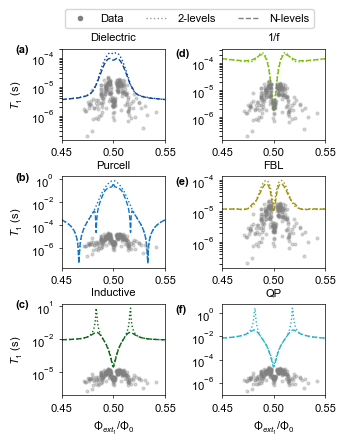

In [71]:
fig = plt.figure()
fig.set_size_inches(3.40457, 4.5)

gs = gridspec.GridSpec(3, 2, hspace=0.4, wspace=0.55)

# Axes
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[2, 0])
ax4 = fig.add_subplot(gs[0, 1])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[2, 1])

axes = [ax1, ax2, ax3, ax4, ax5, ax6]

r = results[dataset_key]
T1_all = r["T1_all_components"]
T1_all_eff = r["T1_eff_all_components"]

# Panels
plot_panel(ax1, phi_ext, T1_all["charge"], T1_all_eff["charge"], color=T1_noise_colors["charge"], title='Dielectric')
plot_panel(ax2, phi_ext, T1_all["purcell"], T1_all_eff["purcell"], color=T1_noise_colors["purcell"], title='Purcell')
plot_panel(ax3, phi_ext, T1_all["inductive"], T1_all_eff["inductive"], color=T1_noise_colors["inductive"], title='Inductive')
plot_panel(ax4, phi_ext, T1_all["one_over_f"], T1_all_eff["one_over_f"], color=T1_noise_colors["one_over_f"], title='1/f')
plot_panel(ax5, phi_ext, T1_all["flux_ohmic"], T1_all_eff["flux_ohmic"], color=T1_noise_colors["flux_ohmic"], title='FBL')
plot_panel(ax6, phi_ext, T1_all["qp"], T1_all_eff["qp"], color=T1_noise_colors["qp"], title='QP')

# Labels
for ax in [ax1, ax2, ax3]:
    ax.set_ylabel("$T_1$ (s)")

for ax in [ax3, ax6]:
    ax.set_xlabel(r"$\Phi_{ext_1}/\Phi_0$")

# ------------------ GLOBAL LEGEND ------------------
legend_elements = [
    Line2D([0], [0], marker='.', color='gray', linestyle='None', label='Data', alpha=1),
    Line2D([0], [0], color='gray', lw=1, linestyle=':', label='2-levels', alpha=0.8),
    Line2D([0], [0], color='gray', lw=1, linestyle='--', label='N-levels')
]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, 0.98), 
    fontsize=8 
)

for ax, label in zip(
        [ax1, ax2, ax3, ],
        ['(a)', '(b)', '(c)']
    ):
        ax.text(-0.45, 1.05, label, transform=ax.transAxes,
                fontweight='bold', va='top')
        
for ax, label in zip(
        [ ax4, ax5, ax6],
        [ '(d)', '(e)', '(f)']
    ):
        ax.text(-0.45, 1.0, label, transform=ax.transAxes,
                fontweight='bold', va='top')
# ------------------ LAYOUT ------------------

fig.savefig("FigS4_N_lvls.pdf", dpi=1200, bbox_inches='tight')
# fig.savefig("N_lvls_new.svg", dpi=1200, bbox_inches='tight')

plt.show()